You are given an array of integers heights where heights[i] represents the height of a bar. The width of each bar is 1.<br>
Return the area of the largest rectangle that can be formed among the bars.<br>
Note: This chart is known as a histogram.<br>
Difficulty: Hard

Input: heights = [7,1,7,2,2,4]<br>
Output: 8

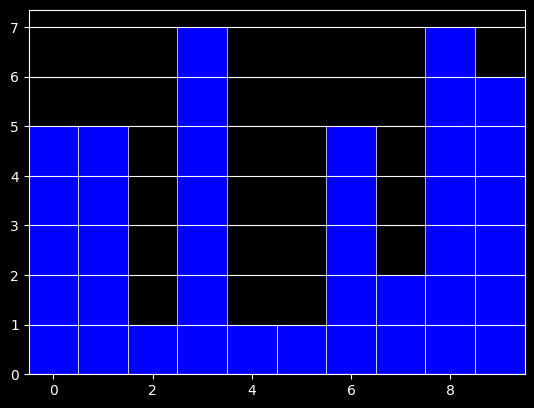

In [9]:
import matplotlib.pyplot as plt

# heights = [7, 1, 7, 2, 2, 4]
# heights = [1, 7, 7, 2, 2, 4]
# heights = [5,1,2,4,5,3,6]
# heights=[1,3,7]
# heights=[0]
# heights = [4,2,0,3,2,5]
# heights=[3,6,5,7,4,8,1,0]
heights=[5,5,1,7,1,1,5,2,7,6]

plt.style.use('dark_background')
plt.bar(range(len(heights)), heights, width=1, color = 'blue', edgecolor='white', linewidth=0.5)
plt.grid(axis='y', color='white')
plt.xlim(-0.5, len(heights) - 0.5)
plt.gca().set_aspect('equal')

plt.show()

In [10]:
from typing import List
class Solution:
    def largestRectangleArea(self, heights: List[int]) -> int:
        stack = []
        for i in range(len(heights)):
            stack.append(heights[i])
            if len(stack) > 2 and stack[-1] < stack[-2] > stack[-3]:
                stack[-2] = max(stack[-3], stack[-1])
        if len(stack) > 1:
            stack[-1] = min(stack[-1], stack[-2])
            stack[0] = min(stack[0], stack[1])
        
        areas = []
        for i in range(len(stack)):
            bar = stack[i]
            area = stack[i]
            count = 1
            zero_seen = False
            for j in stack[i+1:]:
                count += 1
                if j == 0:
                    zero_seen = True
                elif j >= bar and not zero_seen:
                    area += bar
                elif j <= bar and j*count > area and not zero_seen:
                    area = j*count
                elif j <= bar and j*count < area and not zero_seen:
                    break
            areas.append(area)

        return(max(max(areas), max(heights)))

In [11]:
Solution().largestRectangleArea(heights)

12

In [323]:
class Solution_neet:
    def largestRectangleArea(self, heights: List[int]) -> int:
        n = len(heights)
        maxArea = 0

        for i in range(n):
            height = heights[i]

            rightMost = i + 1
            while rightMost < n and heights[rightMost] >= height:
                rightMost += 1

            leftMost = i
            while leftMost >= 0 and heights[leftMost] >= height:
                leftMost -= 1

            rightMost -= 1
            leftMost += 1
            maxArea = max(maxArea, height * (rightMost - leftMost + 1))
        return maxArea

In [337]:
import timeit

gary = Solution()
leet = Solution_neet()

elapsed_time = timeit.timeit('gary.largestRectangleArea(heights)', globals=globals(), number=100000)
print(f"Elapsed time Gary solution: {elapsed_time:.6f} seconds")

elapsed_time = timeit.timeit('leet.largestRectangleArea(heights)', globals=globals(), number=100000)
print(f"Elapsed time Neet solution: {elapsed_time:.6f} seconds")

Elapsed time Gary solution: 0.621035 seconds
Elapsed time Neet solution: 0.407815 seconds
